Ablation study: effect of label corruption on double descent, neural network model.

Produces a figure with a 2x2 panel comparing optimizer (Adam vs. SGD) and label corruption (0% vs 15% - Nakkiran et al. 2019) on the Friedman 1 dataset.

Results: Label corruption is necessary for the double descent peak to appear, regardless of which optimizer is chosen.

Conditions for the ablation study:
    adam_corruption0.0
        Adam optimizer, no corruption
    adam_corruption0.15
        Adam optimizer, 15% label corruption
    sgd_corruption0.0
        SGD with momentum, no corruption
    sgd_corruption0.15
        SGD with momentum, 15% label corruption

Each model was run with N_RUNS=3, epochs = 3000 on Friedman1 (n_train=500).

Run from: figures/nn/
Output: /figures/nn/initial_small_trial_runs/friedman1_ablation_2x2.png

Angie McGraw

Last updated: April 5th, 2026

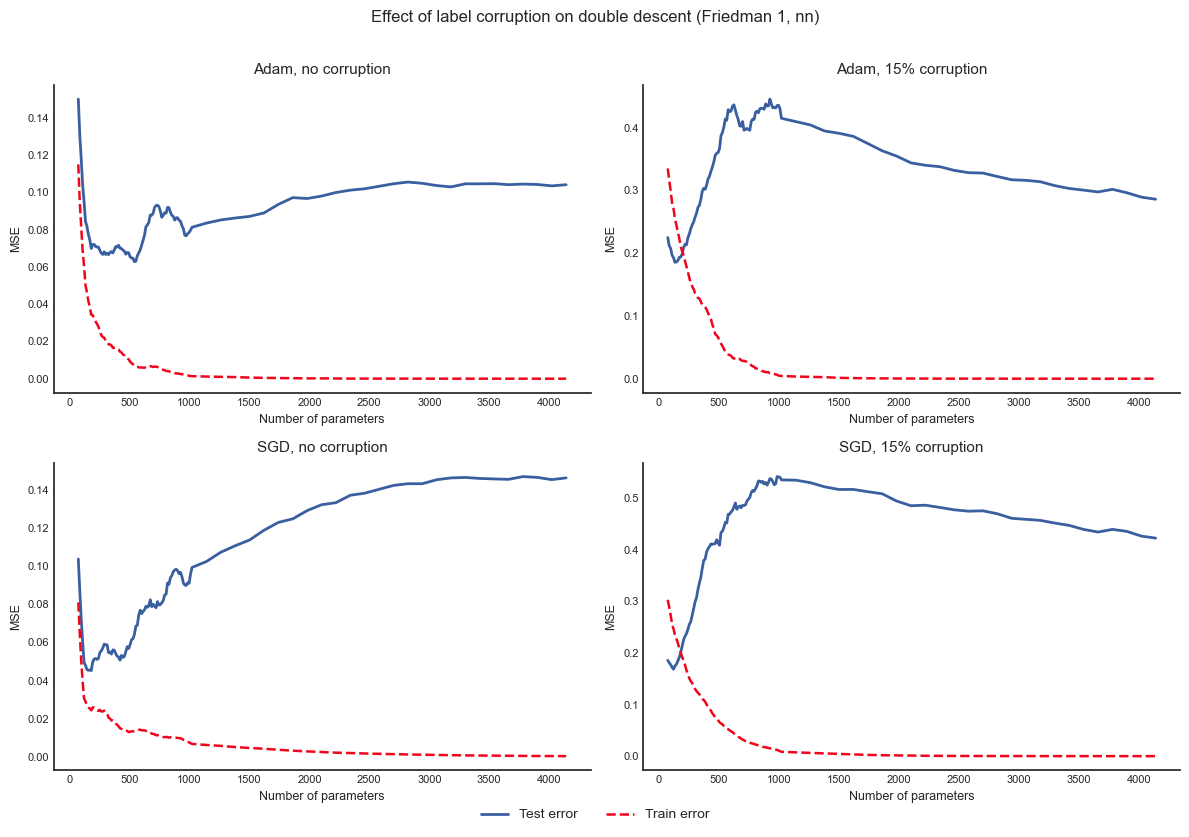

[INFO] Saved to /Users/angiemcgraw/Desktop/double-descent-friedman/figures/nn/initial_small_trial_runs/friedman1_ablation_2x2.png.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from pathlib import Path

plt.style.use('seaborn-v0_8-white')

# Run dictory: figures/nn/
BASE_DIR = Path.cwd() / "initial_small_trial_runs"

def smooth(y, window=11):
    """
    Apply a simple moving average to smooth a noisy curve.
    'same' parameter is used so that the output length matches the input 
    length.

    Later, after smoothing, boundary effects at the curve edges are handled 
    by trimming.
    """
    return np.convolve(y, np.ones(window)/window, mode='same')

def load_condition(condition, dataset="friedman1"):
    """
    Load summary metrics for a given experimental condition (i.e. the four conditions
    mentioned above). 

    Args:
        condition: str
            subfolder ame, e.g. "adam_corruption0.15"
        dataset: str
            dataset name e.g. "friedman1"

    Returns: 
        x: array of parameter counts (sorted, no overlap in the parameter counts)
        train: array of mean train MSE
        test: array of mean test MSE
    """
    path = os.path.join(BASE_DIR, condition, f"{dataset}_metrics_summary.csv")
    df = pd.read_csv(path)
    x = df["params_mean"].values
    train = df["train_mse_mean"].values
    test = df["test_mse_mean"].values
    idx = np.argsort(x) 
    return x[idx], train[idx], test[idx]

"""
2x2
rows: optimizer
cols: corruption (0.0 vs 0.15)
"""
conditions = [
    ("adam_corruption0.0", "Adam, no corruption"),
    ("adam_corruption0.15", "Adam, 15% corruption"),
    ("sgd_corruption0.0", "SGD, no corruption"),
    ("sgd_corruption0.15", "SGD, 15% corruption")
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
fig.patch.set_facecolor('white')

trim = 5
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for (condition, title), (row, col) in zip(conditions, positions):
    ax = axes[row][col]
    x, train, test = load_condition(condition)

    train_s = smooth(train, window=11)[trim:-trim]
    test_s = smooth(test, window=11)[trim:-trim]
    x_s = x[trim:-trim]

    ax.plot(x_s, test_s, linewidth=2.0, linestyle='-', color='#3A5FA0', label='Test error')
    ax.plot(x_s, train_s, linewidth=1.8, linestyle='--', color='#f0051b', label='Train error')

    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel('Number of parameters', fontsize=9)
    ax.set_ylabel('MSE', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)

# Shared legend across all panels
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Effect of label corruption on double descent (Friedman 1, nn)',
             fontsize=12, y=1.01)

plt.tight_layout()
out_path = BASE_DIR / "friedman1_ablation_2x2.png"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print(f"[INFO] Saved to {out_path}.")